In [7]:
import math
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, asdict

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [8]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Plot settings
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)

Device: cuda


Dataset shape: (4320, 2)
Date range: 2025-01-01 00:00:00 – 2025-06-29 23:00:00
Missing values:
 date      0
target    0
dtype: int64


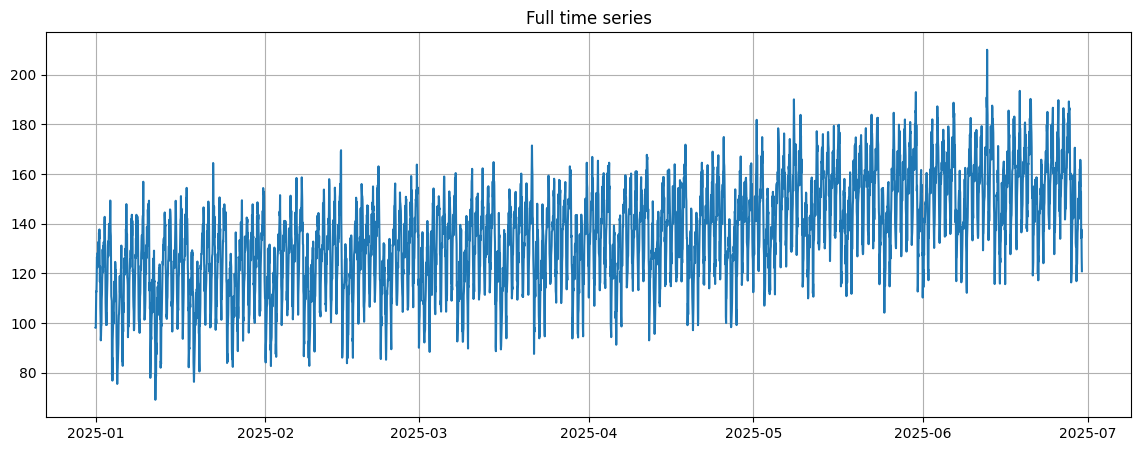

In [9]:
df = pd.read_csv("data/S12-hw-dataset.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print("Dataset shape:", df.shape)
print("Date range:", df["date"].min(), "–", df["date"].max())
print("Missing values:\n", df.isnull().sum())

# Basic plot
fig, ax = plt.subplots()
ax.plot(df["date"], df["target"], lw=1.5)
ax.set_title("Full time series")
plt.show()

Train: 3024 rows, 2025-01-01 00:00:00 – 2025-05-06 23:00:00
Val:   648 rows,   2025-05-07 00:00:00 – 2025-06-02 23:00:00
Test:  648 rows,  2025-06-03 00:00:00 – 2025-06-29 23:00:00


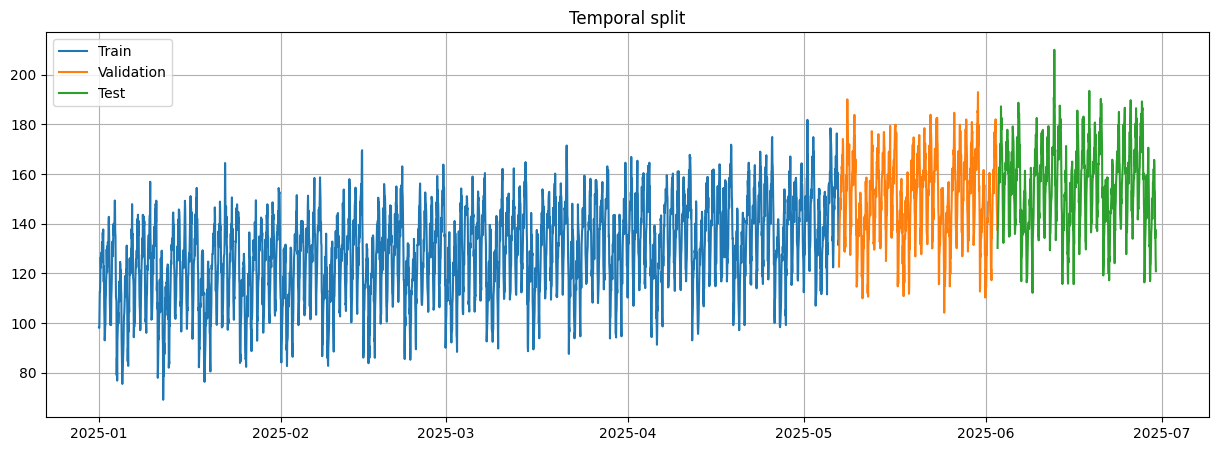

In [11]:
@dataclass
class SplitConfig:
    train_frac: float = 0.70
    val_frac: float = 0.15
    test_frac: float = 0.15

def temporal_split(df, cfg=SplitConfig()):
    n = len(df)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))
    train = df.iloc[:train_end].copy()
    val   = df.iloc[train_end:val_end].copy()
    test  = df.iloc[val_end:].copy()
    return train, val, test

train_df, val_df, test_df = temporal_split(df)
print(f"Train: {len(train_df)} rows, {train_df['date'].min()} – {train_df['date'].max()}")
print(f"Val:   {len(val_df)} rows,   {val_df['date'].min()} – {val_df['date'].max()}")
print(f"Test:  {len(test_df)} rows,  {test_df['date'].min()} – {test_df['date'].max()}")

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(train_df["date"], train_df["target"], label="Train")
ax.plot(val_df["date"],   val_df["target"],   label="Validation")
ax.plot(test_df["date"],  test_df["target"],  label="Test")
ax.legend()
ax.set_title("Temporal split")
plt.savefig("artifacts/figures/series_split.png", bbox_inches="tight")
plt.show()

In [12]:
def add_calendar_features(df):
    out = df.copy()
    out["dayofweek"] = out["date"].dt.dayofweek
    out["month"] = out["date"].dt.month
    return out

def add_lag_features(df, target_col="target", lags=[1, 7, 14], windows=[7, 28]):
    out = df.copy()
    for lag in lags:
        out[f"lag_{lag}"] = out[target_col].shift(lag)
    for w in windows:
        out[f"rolling_mean_{w}"] = out[target_col].shift(1).rolling(w).mean()
        out[f"rolling_std_{w}"]  = out[target_col].shift(1).rolling(w).std()
    return out

def build_feature_set(df):
    df = add_calendar_features(df)
    df = add_lag_features(df)
    df = df.dropna().reset_index(drop=True)
    return df

train_feat = build_feature_set(train_df)
val_feat   = build_feature_set(val_df)
test_feat  = build_feature_set(test_df)

feature_cols = ["lag_1", "lag_7", "lag_14", "rolling_mean_7", "rolling_std_7", "dayofweek", "month"]
target_col = "target"

X_train = train_feat[feature_cols]
y_train = train_feat[target_col]
X_val   = val_feat[feature_cols]
y_val   = val_feat[target_col]
X_test  = test_feat[feature_cols]
y_test  = test_feat[target_col]

print("Feature shapes:", X_train.shape, X_val.shape, X_test.shape)

Feature shapes: (2996, 7) (620, 7) (620, 7)


In [13]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))) * 100

def compute_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mape(y_true, y_pred)
    }

# B1: Naive (last value)
naive_val = train_feat["target"].shift(1).iloc[len(train_feat)-len(val_feat):].values
naive_test = train_feat["target"].shift(1).iloc[len(train_feat)-len(test_feat):].values

# B2: Moving average (window=7)
ma_val = val_feat["rolling_mean_7"].values
ma_test = test_feat["rolling_mean_7"].values

# B3: Ridge on features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_val = ridge.predict(X_val_scaled)
ridge_test = ridge.predict(X_test_scaled)

# Collect results
results = []
for name, y_pred_val, y_pred_test in [
    ("B1 (naive)", naive_val, naive_test),
    ("B2 (moving_avg)", ma_val, ma_test),
    ("B3 (ridge)", ridge_val, ridge_test)
]:
    metrics_val = compute_metrics(y_val, y_pred_val)
    metrics_test = compute_metrics(y_test, y_pred_test)
    results.append({
        "experiment_id": name,
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": 42,
        "split_summary": f"train:{len(train_df)} val:{len(val_df)} test:{len(test_df)}",
        "window_size": None,   # not used for baselines
        "horizon": 1,
        "model_summary": name,
        "features_summary": "lag1,lag7,lag14,rolling_mean7,rolling_std7,dayofweek,month" if "ridge" in name else "none",
        "scaler": "StandardScaler" if "ridge" in name else "none",
        "optimizer": "none",
        "lr": None,
        "epochs_trained": None,
        "best_val_mae": metrics_val["MAE"],
        "best_val_rmse": metrics_val["RMSE"],
        "best_val_mape": metrics_val["MAPE"],
        "test_mae": metrics_test["MAE"],
        "test_rmse": metrics_test["RMSE"],
        "test_mape": metrics_test["MAPE"],
        "notes": ""
    })

In [14]:
window_size = 28
def create_sequences(series, window_size):
    X, y = [], []
    for i in range(len(series) - window_size):
        X.append(series[i : i + window_size])
        y.append(series[i + window_size])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Scale only using training data
scaler_target = StandardScaler()
train_scaled = scaler_target.fit_transform(train_df[["target"]]).flatten()
val_scaled   = scaler_target.transform(val_df[["target"]]).flatten()
test_scaled  = scaler_target.transform(test_df[["target"]]).flatten()

X_train_seq, y_train_seq = create_sequences(train_scaled, window_size)
X_val_seq, y_val_seq     = create_sequences(val_scaled, window_size)
X_test_seq, y_test_seq   = create_sequences(test_scaled, window_size)

In [15]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # (N, window, 1)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 64
train_ds = TimeSeriesDataset(X_train_seq, y_train_seq)
val_ds   = TimeSeriesDataset(X_val_seq, y_val_seq)
test_ds  = TimeSeriesDataset(X_test_seq, y_test_seq)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

In [16]:
class GRUForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=48, num_layers=2, dropout=0.2):
        super().__init__()
        self.rnn = nn.GRU(input_size, hidden_size, num_layers,
                          batch_first=True, dropout=dropout if num_layers>1 else 0)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.rnn(x)                # (batch, seq, hidden)
        last = out[:, -1, :]                # (batch, hidden)
        return self.fc(last).squeeze(-1)    # (batch,)

gru_model = GRUForecaster().to(device)
print("GRU parameters:", sum(p.numel() for p in gru_model.parameters()))

GRU parameters: 21505


In [17]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(gru_model.parameters(), lr=1e-3)
epochs = 30
best_val_loss = float("inf")
best_state = None
train_losses = []
val_losses = []

for epoch in range(1, epochs+1):
    gru_model.train()
    epoch_loss = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = gru_model(Xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * Xb.size(0)
    train_loss = epoch_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    gru_model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            pred = gru_model(Xb)
            loss = criterion(pred, yb)
            epoch_loss += loss.item() * Xb.size(0)
    val_loss = epoch_loss / len(val_loader.dataset)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = gru_model.state_dict().copy()

    if epoch % 5 == 0:
        print(f"Epoch {epoch:2d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

# Restore best model
gru_model.load_state_dict(best_state)
print("Best val loss:", best_val_loss)

Epoch  5 | train_loss=0.152964 | val_loss=0.223823
Epoch 10 | train_loss=0.123658 | val_loss=0.225578
Epoch 15 | train_loss=0.105579 | val_loss=0.172027
Epoch 20 | train_loss=0.099707 | val_loss=0.160197
Epoch 25 | train_loss=0.100564 | val_loss=0.164661
Epoch 30 | train_loss=0.101678 | val_loss=0.175839
Best val loss: 0.15240282863378524


In [18]:
gru_model.eval()
with torch.no_grad():
    preds_scaled = []
    trues_scaled = []
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        pred = gru_model(Xb).cpu().numpy()
        preds_scaled.append(pred)
        trues_scaled.append(yb.numpy())
preds_scaled = np.concatenate(preds_scaled)
trues_scaled = np.concatenate(trues_scaled)

# Inverse scaling
preds = scaler_target.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
trues = scaler_target.inverse_transform(trues_scaled.reshape(-1, 1)).flatten()

metrics_test = compute_metrics(trues, preds)
print("GRU test metrics:", metrics_test)

# Add GRU results to runs.csv
results.append({
    "experiment_id": "R1 (GRU)",
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": 42,
    "split_summary": f"train:{len(train_df)} val:{len(val_df)} test:{len(test_df)}",
    "window_size": window_size,
    "horizon": 1,
    "model_summary": f"GRU(hidden=48,layers=2,dropout=0.2)",
    "features_summary": f"window_{window_size}",
    "scaler": "StandardScaler (target only)",
    "optimizer": "Adam",
    "lr": 1e-3,
    "epochs_trained": epochs,
    "best_val_mae": None,  # we didn't compute MAE during training; could be added if needed
    "best_val_rmse": None,
    "best_val_mape": None,
    "test_mae": metrics_test["MAE"],
    "test_rmse": metrics_test["RMSE"],
    "test_mape": metrics_test["MAPE"],
    "notes": "Best model selected by val loss"
})

GRU test metrics: {'MAE': 7.44558048248291, 'RMSE': np.float64(9.385681577635042), 'MAPE': np.float32(4.732039)}


In [20]:
import os
os.makedirs("artifacts/figures", exist_ok=True)

# 1. runs.csv
runs_df = pd.DataFrame(results)
runs_df.to_csv("artifacts/runs.csv", index=False)

# 2. Best GRU model
torch.save(best_state, "artifacts/best_gru.pt")

# 3. Best GRU config
config = {
    "model": "GRU",
    "input_size": 1,
    "hidden_size": 48,
    "num_layers": 2,
    "dropout": 0.2,
    "window_size": window_size,
    "batch_size": batch_size,
    "learning_rate": 1e-3,
    "epochs": epochs,
    "best_val_loss": best_val_loss,
    "scaler": "StandardScaler",
    "scaler_mean": scaler_target.mean_.tolist(),
    "scaler_scale": scaler_target.scale_.tolist(),
    "seed": 42
}
with open("artifacts/best_gru_config.json", "w") as f:
    json.dump(config, f, indent=2)

# 4. Figures

# baselines_compare.png (bar plot of MAE on validation)
val_mae = [r["best_val_mae"] for r in results if "best_val_mae" in r and r["best_val_mae"] is not None]
labels = [r["experiment_id"] for r in results if "best_val_mae" in r and r["best_val_mae"] is not None]
plt.figure()
plt.bar(labels, val_mae, color=['gray', 'lightblue', 'orange'])
plt.title("Validation MAE comparison")
plt.ylabel("MAE")
plt.savefig("artifacts/figures/baselines_compare.png", bbox_inches="tight")
plt.close()

# gru_learning_curves.png
plt.figure()
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.title("GRU learning curves")
plt.savefig("artifacts/figures/gru_learning_curves.png", bbox_inches="tight")
plt.close()

# best_forecast_test.png (actual vs prediction for best model)
# We need to align dates. The test_df starts after window_size due to sequence creation.
test_dates = test_df["date"].iloc[window_size:].reset_index(drop=True)
plt.figure(figsize=(12, 5))
plt.plot(test_dates, trues, label="Actual")
plt.plot(test_dates, preds, label="GRU forecast")
plt.legend()
plt.title("Best model (GRU) forecast on test set")
plt.savefig("artifacts/figures/best_forecast_test.png", bbox_inches="tight")
plt.close()

print("All artifacts saved successfully.")

All artifacts saved successfully.
